In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [2]:
torch.set_num_threads(8)
device = torch.device("cpu")


In [3]:
data = np.load(r"C:\Users\ASUS\Downloads\PEMS08.npz\PEMS08.npz")
arr = data['data']
flow = arr[:,:,0]


In [4]:
split_index = int(0.8 * len(flow))
train_flow = flow[:split_index]

mean = train_flow.mean()
std  = train_flow.std()

flow = (flow - mean) / std


In [5]:
SEQ_LEN = 36
PRED_LEN = 1

X=[]
Y=[]

for i in range(len(flow)-SEQ_LEN-PRED_LEN):
    X.append(flow[i:i+SEQ_LEN])
    Y.append(flow[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])

X=np.array(X)
Y=np.array(Y)


In [6]:
split=int(0.8*len(X))

X_train_full=X[:split]
Y_train_full=Y[:split]

X_test=X[split:]
Y_test=Y[split:]

val_split=int(0.9*len(X_train_full))

X_train=X_train_full[:val_split]
Y_train=Y_train_full[:val_split]

X_val=X_train_full[val_split:]
Y_val=Y_train_full[val_split:]


In [7]:
class TrafficDataset(Dataset):
    def __init__(self,X,Y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.Y=torch.tensor(Y,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx],self.Y[idx]

train_loader=DataLoader(TrafficDataset(X_train,Y_train),batch_size=64,shuffle=True)
val_loader=DataLoader(TrafficDataset(X_val,Y_val),batch_size=64)
test_loader=DataLoader(TrafficDataset(X_test,Y_test),batch_size=64)


In [8]:
class GRUTransformer(nn.Module):
    def __init__(self,sensors=170,hidden=128):
        super().__init__()

        self.gru = nn.GRU(
            input_size=sensors,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=8,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=3)
        self.fc = nn.Linear(hidden,sensors)

    def forward(self,x):
        x,_ = self.gru(x)
        x = self.transformer(x)
        x = self.fc(x[:,-1,:])
        return x.unsqueeze(1)


In [9]:
model=GRUTransformer().to(device)

optimizer=torch.optim.Adam(model.parameters(),lr=0.00012)
criterion=nn.MSELoss()

EPOCHS=100
patience=10
best_val_loss=float("inf")
patience_counter=0

for epoch in range(EPOCHS):

    model.train()
    train_loss=0

    for x,y in train_loader:
        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()
        pred=model(x)
        loss=criterion(pred,y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()

        train_loss+=loss.item()

    train_loss/=len(train_loader)

    model.eval()
    val_loss=0

    with torch.no_grad():
        for x,y in val_loader:
            x,y=x.to(device),y.to(device)
            val_loss+=criterion(model(x),y).item()

    val_loss/=len(val_loader)

    print(f"Epoch {epoch+1}, Train {train_loss:.4f}, Val {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss=val_loss
        patience_counter=0
        torch.save(model.state_dict(),"best_gru_model.pth")
    else:
        patience_counter+=1

    if patience_counter>=patience:
        print("Early stopping triggered")
        break

model.load_state_dict(torch.load("best_gru_model.pth"))


Epoch 1, Train 0.2288, Val 0.1349
Epoch 2, Train 0.0726, Val 0.1137
Epoch 3, Train 0.0567, Val 0.1047
Epoch 4, Train 0.0485, Val 0.0981
Epoch 5, Train 0.0435, Val 0.0927
Epoch 6, Train 0.0398, Val 0.0877
Epoch 7, Train 0.0373, Val 0.0846
Epoch 8, Train 0.0355, Val 0.0802
Epoch 9, Train 0.0339, Val 0.0781
Epoch 10, Train 0.0327, Val 0.0756
Epoch 11, Train 0.0316, Val 0.0720
Epoch 12, Train 0.0308, Val 0.0698
Epoch 13, Train 0.0300, Val 0.0686
Epoch 14, Train 0.0293, Val 0.0665
Epoch 15, Train 0.0287, Val 0.0656
Epoch 16, Train 0.0281, Val 0.0636
Epoch 17, Train 0.0276, Val 0.0617
Epoch 18, Train 0.0272, Val 0.0610
Epoch 19, Train 0.0268, Val 0.0599
Epoch 20, Train 0.0264, Val 0.0589
Epoch 21, Train 0.0260, Val 0.0575
Epoch 22, Train 0.0257, Val 0.0561
Epoch 23, Train 0.0254, Val 0.0553
Epoch 24, Train 0.0251, Val 0.0554
Epoch 25, Train 0.0248, Val 0.0551
Epoch 26, Train 0.0245, Val 0.0536
Epoch 27, Train 0.0243, Val 0.0536
Epoch 28, Train 0.0241, Val 0.0533
Epoch 29, Train 0.0239, Val 0

<All keys matched successfully>

MAE: 16.378521087500953
RMSE: 24.64656047741695
MAPE: 172765.97670037972


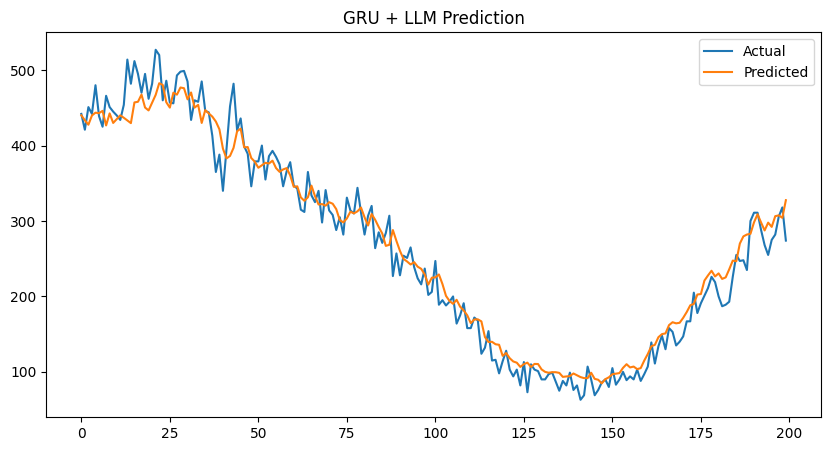

In [10]:
model.eval()

preds=[]
actual=[]

with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)
        preds.append(model(x).cpu().numpy())
        actual.append(y.numpy())

preds=np.concatenate(preds)
actual=np.concatenate(actual)

preds = preds*std + mean
actual = actual*std + mean

mae  = mean_absolute_error(actual.flatten(),preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(),preds.flatten()))
mape = np.mean(np.abs((actual.flatten()-preds.flatten())/(actual.flatten()+1e-5)))*100

print("MAE:",mae)
print("RMSE:",rmse)
print("MAPE:",mape)

plt.figure(figsize=(10,5))
plt.plot(actual[:200,0,0],label="Actual")
plt.plot(preds[:200,0,0],label="Predicted")
plt.legend()
plt.title("GRU + LLM Prediction")
plt.show()
